<a href="https://colab.research.google.com/github/VSUrhuel/forage-classifications/blob/main/Progressive_Efficientnet_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input #
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import numpy as np
import os

In [11]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
BASE_DIR = '/content/drive/MyDrive/Undergrad Thesis/Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
SAVE_PATH = '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/efficientnetv2_finetuned_ver4.keras'

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 14

In [14]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=[0.9, 1.1],
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [15]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3577 images belonging to 14 classes.
Found 763 images belonging to 14 classes.


In [16]:
print("\nComputing Class Weights...")
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print(f"Weights: {class_weights_dict}")


Computing Class Weights...
Weights: {0: np.float64(0.998046875), 1: np.float64(1.0780590717299579), 2: np.float64(0.9324817518248175), 3: np.float64(1.0179282868525896), 4: np.float64(0.9569288389513109), 5: np.float64(0.9462962962962963), 6: np.float64(1.0735294117647058), 7: np.float64(1.0557851239669422), 8: np.float64(1.0179282868525896), 9: np.float64(0.9533582089552238), 10: np.float64(0.9428044280442804), 11: np.float64(1.0872340425531914), 12: np.float64(1.0179282868525896), 13: np.float64(0.9605263157894737)}


In [9]:
# Building the model
print("\nBuilding Model...")

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

# Pyramid Head (Stronger capacity for the stronger model)
x = layers.Dense(512)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)


Building Model...


In [17]:
def unfreeze_layers(num_layers_to_unfreeze):
    """
    Unfreezes the top N layers of the GLOBAL base_model.
    """
    base_model.trainable = True

    # 1. Re-freeze EVERYTHING inside it first
    for layer in base_model.layers:
        layer.trainable = False

    # 2. Unfreeze only the specific last N layers (Excluding Batch Norm)
    unfrozen_count = 0
    for layer in base_model.layers[-num_layers_to_unfreeze:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
            unfrozen_count += 1

    print(f"\nSTATUS: Unfrozen top {num_layers_to_unfreeze} backbone layers (Actual trainable: {unfrozen_count}).")
    print(f"        (Batch Normalization layers kept frozen for stability)")

In [18]:
# --- ROUND 1: TRAIN HEAD ONLY ---
print("\n========== ROUND 1: Training Head (10 Epochs) ==========")
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_r1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict
)


========== ROUND 1: Training Head (10 Epochs) ==========


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1818s 16s/step - accuracy: 0.5914 - loss: 1.2746 - val_accuracy: 0.8178 - val_loss: 0.5953
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 478ms/step - accuracy: 0.8146 - loss: 0.5303 - val_accuracy: 0.8834 - val_loss: 0.3427
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 476ms/step - accuracy: 0.8388 - loss: 0.4307 - val_accuracy: 0.8598 - val_loss: 0.3825
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 476ms/step - accuracy: 0.8770 - loss: 0.3760 - val_accuracy: 0.8755 - val_loss: 0.3455
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 479ms/step - accuracy: 0.8838 - loss: 0.3196 - val_accuracy: 0.8952 - val_loss: 0.3143
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 473ms/step - accuracy: 0.9015 - loss: 0.2885 - val_accuracy: 0.9004 - val_loss: 0.2902
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 474ms/step - accuracy: 0.8932 - loss: 0.2952 - val_accuracy: 0.8847 - val_loss: 0.3597
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 478ms/step - accuracy: 0.8998 - loss: 0

In [19]:
# --- ROUND 2: UNFREEZE TOP 50 LAYERS ---
print("\n========== ROUND 2: Unfreeze Top 50 (10 Epochs) ==========")
unfreeze_layers(50) # EfficientNet is deep, so we unfreeze 50

model.compile(
    optimizer=optimizers.Adam(learning_rate=2e-4), # Lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_r2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict
)


========== ROUND 2: Unfreeze Top 50 (10 Epochs) ==========

STATUS: Unfrozen top 50 backbone layers (Actual trainable: 40).
        (Batch Normalization layers kept frozen for stability)
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 120s 771ms/step - accuracy: 0.9118 - loss: 0.2384 - val_accuracy: 0.9174 - val_loss: 0.2351
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 478ms/step - accuracy: 0.9369 - loss: 0.1752 - val_accuracy: 0.9410 - val_loss: 0.1826
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 476ms/step - accuracy: 0.9596 - loss: 0.1302 - val_accuracy: 0.9240 - val_loss: 0.2055
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 474ms/step - accuracy: 0.9621 - loss: 0.1167 - val_accuracy: 0.9371 - val_loss: 0.1911
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 475ms/step - accuracy: 0.9605 - loss: 0.1214 - val_accuracy: 0.9292 - val_loss: 0.2162
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 478ms/step - accuracy: 0.9619 - loss: 0.1071 - val_accuracy: 0.9253 - val_loss: 0.2209
Epoch 7/10
112/112 ━━━━━━

In [22]:
# --- ROUND 3: UNFREEZE TOP 100 LAYERS ---
print("\n========== ROUND 3: Unfreeze Top 100 (20 Epochs) ==========")
unfreeze_layers(100) # Deep fine-tuning

es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = callbacks.ModelCheckpoint(SAVE_PATH, save_best_only=True, monitor='val_accuracy')

model.compile(
    optimizer=optimizers.Adam(learning_rate=4e-5), # Lowest LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_r3 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    callbacks=[es, mc]
)

print("Training Complete. EfficientNet Progressive Model saved.")


========== ROUND 3: Unfreeze Top 100 (20 Epochs) ==========

STATUS: Unfrozen top 100 backbone layers (Actual trainable: 80).
        (Batch Normalization layers kept frozen for stability)
Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 123s 785ms/step - accuracy: 0.9798 - loss: 0.0737 - val_accuracy: 0.9567 - val_loss: 0.1334
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 491ms/step - accuracy: 0.9790 - loss: 0.0640 - val_accuracy: 0.9581 - val_loss: 0.1277
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 55s 488ms/step - accuracy: 0.9840 - loss: 0.0555 - val_accuracy: 0.9528 - val_loss: 0.1231
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 477ms/step - accuracy: 0.9887 - loss: 0.0436 - val_accuracy: 0.9567 - val_loss: 0.1228
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 474ms/step - accuracy: 0.9854 - loss: 0.0449 - val_accuracy: 0.9502 - val_loss: 0.1434
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 474ms/step - accuracy: 0.9860 - loss: 0.0479 - val_accuracy: 0.9515 - val_loss: 0.1529
Epoch 7/20
112/112 ━━━━

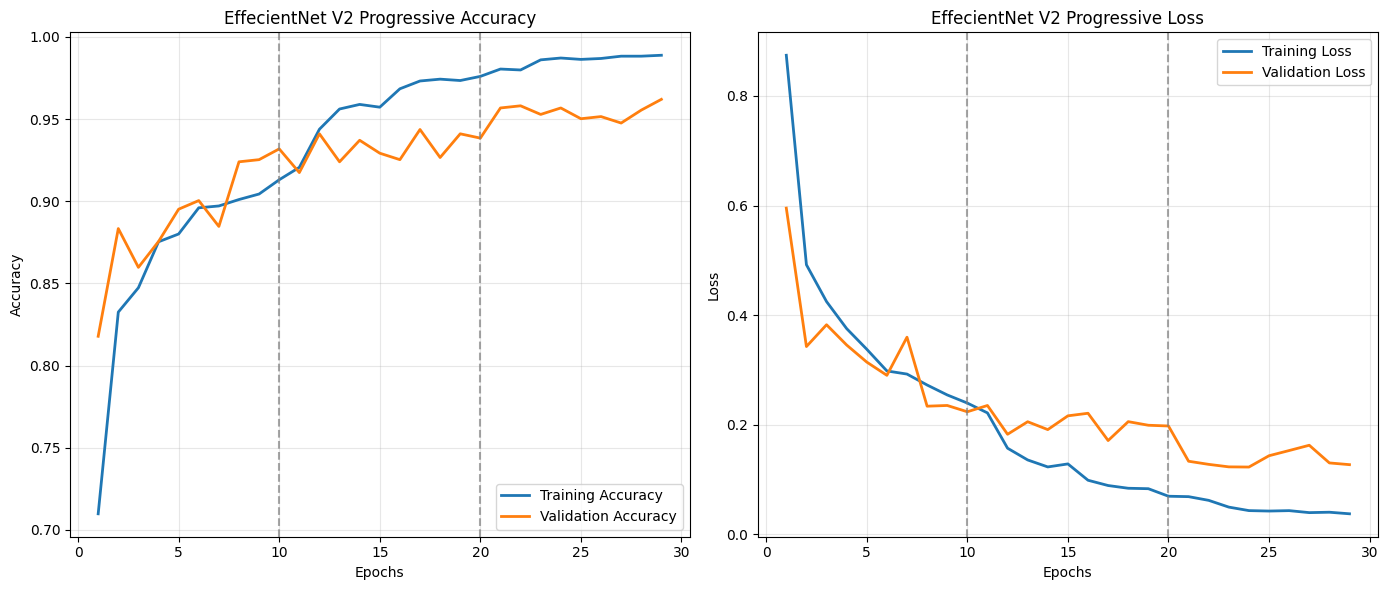

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_thesis_history(h1, h2, h3):
    # 1. Combine the histories into single lists
    acc = h1.history['accuracy'] + h2.history['accuracy'] + h3.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy'] + h3.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss'] + h3.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss'] + h3.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # 2. Calculate where the phases switch
    phase1_end = len(h1.history['accuracy'])
    phase2_end = phase1_end + len(h2.history['accuracy'])

    # 3. Setup the Plot
    plt.figure(figsize=(14, 6))

    # --- SUBPLOT 1: ACCURACY ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)

    # Add vertical lines for phases
    plt.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7)
    plt.axvline(x=phase2_end, color='gray', linestyle='--', alpha=0.7)

    plt.title('EffecientNet V2 Progressive Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # --- SUBPLOT 2: LOSS ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

    # Add vertical lines
    plt.axvline(x=phase1_end, color='gray', linestyle='--', alpha=0.7)
    plt.axvline(x=phase2_end, color='gray', linestyle='--', alpha=0.7)

    plt.title('EffecientNet V2 Progressive Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save for Thesis
    plt.savefig('mobilenet_progressive_training.png', dpi=300)
    plt.show()

# Run it
plot_thesis_history(history_r1, history_r2, history_r3)